## 1. Import et chargement des données

In [ ]:
#importation du module sys pour manipuler le chemin d'accès aux modules
import sys 
# Ajout du chemin parent au chemin d'accès aux modules
sys.path.append('..') 
#importation de la bibliothèque pandas pour la manipulation des données
import pandas as pd 
#importation de la bibliothèque matplotlib pour la visualisation des données
import matplotlib.pyplot as plt 
#importation de la classe Counter pour compter les occurrences des éléments dans une liste
from collections import Counter 
#importation de la fonction load_and_prepare_data pour charger et préparer les données
from src.preprocessing import load_and_prepare_data 
# chargement et préparation des données à partir du fichier CSV
df = load_and_prepare_data('../data/spam.csv') 
#affichage des 5 premières lignes du DataFrame
df.head() 

[nltk_data] Error loading own-1.4: Package 'own-1.4' not found in
[nltk_data]     index


,label,text,clean_text,target
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,1
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he go to usf he live around h...,0


 ## 2. Inspection générale

In [12]:
#le nombre de lignes et de colonnes
print(df.shape) 
#les types de données et les valeurs manquantes
df.info() 
#les dodonnées manquantes
print("Valeurs manquantes:\n", df.isnull().sum()) 
#les doublons
print("Doublons:", df.duplicated().sum()) 

(5169, 4)
<class 'pandas.DataFrame'>
RangeIndex: 5169 entries, 0 to 5168
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   label       5169 non-null   str  
 1   text        5169 non-null   str  
 2   clean_text  5169 non-null   str  
 3   target      5169 non-null   int64
dtypes: int64(1), str(3)
memory usage: 929.6 KB
Valeurs manquantes:
 label         0
text          0
clean_text    0
target        0
dtype: int64
Doublons: 0


## 3. Distribution spam vs ham

label
ham     4516
spam     653
Name: count, dtype: int64


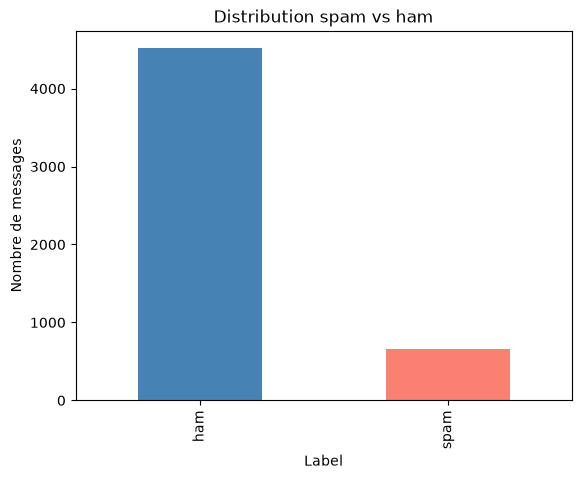

In [13]:
#affichage du nombre de messages spam et ham
print(df['label'].value_counts()) 
#chart en barres pour visualiser la distribution des messages spam et ham
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon']) 
#titre du graphique
plt.title('Distribution spam vs ham') 
#nom de l'axe des x
plt.xlabel('Label')
#nom de l'axe des y
plt.ylabel('Nombre de messages')
#l'Affichage du graphique
plt.show()

## 4. Longueur des messages

label
ham      70.459256
spam    137.891271
Name: msg_length, dtype: float64


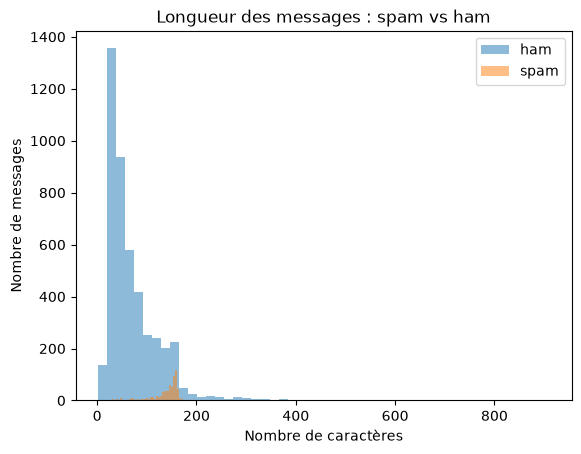

In [14]:
#calcul de la longueur de chaque message
df['msg_length'] = df['text'].apply(len) 
#affichage de la longueur moyenne des messages pour chaque label
print(df.groupby('label')['msg_length'].mean()) 
#affichage de l'histogramme pour les messages ham
df[df['label']=='ham']['msg_length'].plot(kind='hist', bins=50, alpha=0.5, label='ham') 
#affichage de l'histogramme pour les messages spam
df[df['label']=='spam']['msg_length'].plot(kind='hist', bins=50, alpha=0.5, label='spam') 
#affichage de la légende
plt.legend() 
#titre du graphique
plt.title('Longueur des messages : spam vs ham') 
#nom de l'axe des x
plt.xlabel('Nombre de caractères') 
#nom de l'axe des y
plt.ylabel('Nombre de messages') 
#l'affichage du graphique
plt.show() 

## 5. Mots fréquents

In [15]:
#fonction pour obtenir les n mots les plus fréquents dans une série de texte
def top_words(text_series, n=15): 
    words = ' '.join(text_series).split() #joint tous les textes en une seule chaîne et les divise en mots
    return Counter(words).most_common(n) #retourne les n mots les plus fréquents et leur nombre d'occurrences

#affichage des n mots les plus fréquents dans les messages spam
print("Top mots SPAM:", top_words(df[df['label']=='spam']['clean_text'])) 
#affichage des n mots les plus fréquents dans les messages ham
print("Top mots HAM:", top_words(df[df['label']=='ham']['clean_text'])) 

Top mots SPAM: [('to', 594), ('a', 359), ('be', 328), ('call', 324), ('you', 259), ('your', 241), ('free', 190), ('for', 185), ('the', 181), ('have', 158), ('now', 157), ('or', 157), ('u', 137), ('txt', 127), ('text', 121)]
Top mots HAM: [('i', 2075), ('be', 1957), ('you', 1773), ('to', 1474), ('a', 1072), ('the', 1048), ('u', 941), ('it', 832), ('and', 818), ('in', 753), ('me', 723), ('my', 668), ('have', 610), ('do', 605), ('get', 592)]


In [4]:
import pandas as pd
df_nazario = pd.read_csv('../data/Nazario.csv')
print(df_nazario.columns.tolist())
print(df_nazario.shape)
df_nazario.head()

['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
(1565, 7)


,sender,receiver,date,subject,body,urls,label
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1
2,Microsoft Outlook <recepcao@unimedceara.com.br>,NaN,"Fri, 30 Oct 2015 06:21:59 -0300 (BRT)",Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1,1
3,Ann Garcia <AnGarcia@mcoe.org>,"""info@maaaaa.org"" <info@maaaaa.org>","Fri, 30 Oct 2015 14:54:33 +0000",IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,0,1
4,"""USAA"" <usaaacctupdate@sccu4u.com>",Recipients <usaaacctupdate@sccu4u.com>,"Fri, 30 Oct 2015 14:02:33 -0500",Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1,1


In [5]:
df_en = pd.read_csv('../data/spam.csv', encoding='latin-1')
df_en = df_en[['v1', 'v2']]
df_en.columns = ['label', 'text']

df_nazario_raw = pd.read_csv('../data/Nazario.csv')
df_nazario = df_nazario_raw[df_nazario_raw['label'] == 1].copy()
df_nazario['text'] = df_nazario['subject'].fillna('') + ' ' + df_nazario['body'].fillna('')
df_nazario['label'] = 'spam'
df_nazario = df_nazario[['label', 'text']]

df_combined = pd.concat([df_en, df_nazario], ignore_index=True)
df_combined = df_combined.drop_duplicates(subset='text').reset_index(drop=True)

print(df_combined.shape)
print(df_combined['label'].value_counts())

df_combined.to_csv('../data/spam_with_phishing.csv', index=False, encoding='utf-8')
print("Sauvegarde dans data/spam_with_phishing.csv")

(6734, 2)
label
ham     4516
spam    2218
Name: count, dtype: int64
Sauvegarde dans data/spam_with_phishing.csv
